<a href="https://colab.research.google.com/github/sariyya-aliyeva/Intrusion_Detection_Systems/blob/main/2_Stage1_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# STAGE 1: AUTOENCODER ANOMALY DETECTION
# =========================

benign_class = list(label_encoder.classes_).index("BENIGN")

X_train_benign = X_train_scaled[y_train == benign_class]

print("Benign class index:", benign_class)
print("Benign training shape:", X_train_benign.shape)

X_train_benign_tensor = torch.tensor(X_train_benign, dtype=torch.float32).to(device)


class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


input_dim = X_train_benign_tensor.shape[1]

autoencoder = Autoencoder(input_dim).to(device)

criterion_ae = nn.MSELoss()
optimizer_ae = optim.Adam(autoencoder.parameters(), lr=0.0005)

print(autoencoder)

Benign class index: 0
Benign training shape: (318479, 78)
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=78, bias=True)
  )
)


In [ ]:
# =========================
# TRAIN AUTOENCODER
# =========================

epochs_ae = 15
batch_size_ae = 256

ae_losses = []

for epoch in range(epochs_ae):
    autoencoder.train()

    perm = torch.randperm(X_train_benign_tensor.size(0))
    epoch_loss = 0.0
    batch_count = 0

    for i in range(0, X_train_benign_tensor.size(0), batch_size_ae):
        batch = X_train_benign_tensor[perm[i:i + batch_size_ae]]

        optimizer_ae.zero_grad()
        reconstructed = autoencoder(batch)

        loss = criterion_ae(reconstructed, batch)
        loss.backward()
        optimizer_ae.step()

        epoch_loss += loss.item()
        batch_count += 1

    avg_loss = epoch_loss / batch_count
    ae_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs_ae} | Autoencoder Loss: {avg_loss:.6f}")

Epoch 1/15 | Autoencoder Loss: 0.347482
Epoch 2/15 | Autoencoder Loss: 0.123094
Epoch 3/15 | Autoencoder Loss: 0.062992
Epoch 4/15 | Autoencoder Loss: 0.062549
Epoch 5/15 | Autoencoder Loss: 0.041039
Epoch 6/15 | Autoencoder Loss: 0.077693
Epoch 7/15 | Autoencoder Loss: 0.031473
Epoch 8/15 | Autoencoder Loss: 0.032925
Epoch 9/15 | Autoencoder Loss: 0.036204
Epoch 10/15 | Autoencoder Loss: 0.022895
Epoch 11/15 | Autoencoder Loss: 0.049949
Epoch 12/15 | Autoencoder Loss: 0.023302
Epoch 13/15 | Autoencoder Loss: 0.021752
Epoch 14/15 | Autoencoder Loss: 0.039874
Epoch 15/15 | Autoencoder Loss: 0.022086


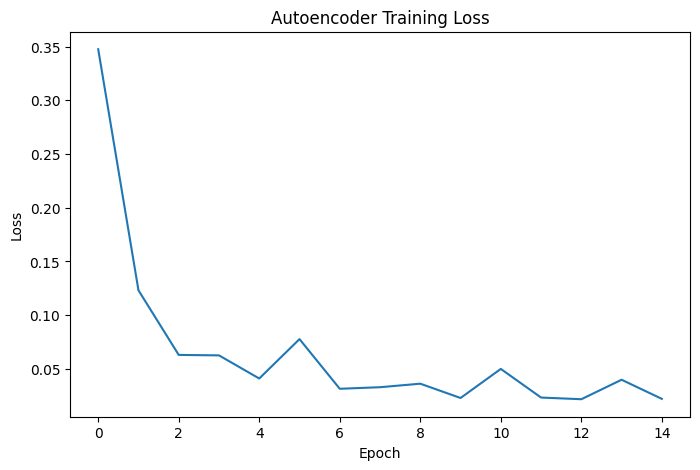

In [ ]:
# =========================
# AUTOENCODER LOSS CURVE
# =========================

plt.figure(figsize=(8,5))
plt.plot(ae_losses)
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# =========================
# RECONSTRUCTION ERROR CALCULATION
# =========================

X_val_benign = X_val_scaled[y_val == benign_class]

X_val_benign_tensor = torch.tensor(X_val_benign, dtype=torch.float32).to(device)
X_val_all_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)

autoencoder.eval()

with torch.no_grad():
    recon_val_benign = autoencoder(X_val_benign_tensor)
    errors_val_benign = torch.mean(
        (X_val_benign_tensor - recon_val_benign) ** 2,
        dim=1
    ).cpu().numpy()

with torch.no_grad():
    recon_val_all = autoencoder(X_val_all_tensor)
    errors_val_all = torch.mean(
        (X_val_all_tensor - recon_val_all) ** 2,
        dim=1
    ).cpu().numpy()

print("Benign validation shape:", X_val_benign.shape)
print("Mean reconstruction error:", errors_val_benign.mean())
print("Std reconstruction error:", errors_val_benign.std())

Benign validation shape: (68246, 78)
Mean reconstruction error: 0.014149826
Std reconstruction error: 0.15189472


In [ ]:
# =========================
# THRESHOLD METHOD 1: MEAN + 3*STD
# =========================

y_val_binary = (y_val != benign_class).astype(int)

threshold_mean_std = errors_val_benign.mean() + 3 * errors_val_benign.std()
y_pred_mean_std = (errors_val_all > threshold_mean_std).astype(int)

print("Threshold method: Mean + 3*STD")
print("Threshold value:", threshold_mean_std)

print("\nClassification Report:")
print(classification_report(y_val_binary, y_pred_mean_std, zero_division=0))

print("\nConfusion Matrix:")
cm_mean_std = confusion_matrix(y_val_binary, y_pred_mean_std)
print(cm_mean_std)

Threshold method: Mean + 3*STD
Threshold value: 0.46983397

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90     68246
           1       0.96      0.21      0.34     19826

    accuracy                           0.82     88072
   macro avg       0.89      0.60      0.62     88072
weighted avg       0.85      0.82      0.77     88072


Confusion Matrix:
[[68087   159]
 [15678  4148]]


In [ ]:
# =========================
# THRESHOLD METHOD 2: PERCENTILE-BASED TUNING
# =========================

percentiles = [90, 95, 97, 99]
threshold_results = []

for p in percentiles:
    threshold = np.percentile(errors_val_benign, p)
    y_pred = (errors_val_all > threshold).astype(int)

    report = classification_report(
        y_val_binary,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    threshold_results.append({
        "Percentile": p,
        "Threshold": threshold,
        "Accuracy": report["accuracy"],
        "Attack Precision": report["1"]["precision"],
        "Attack Recall": report["1"]["recall"],
        "Attack F1-score": report["1"]["f1-score"],
        "Macro F1-score": report["macro avg"]["f1-score"],
        "Weighted F1-score": report["weighted avg"]["f1-score"]
    })

threshold_results_df = pd.DataFrame(threshold_results)
display(threshold_results_df)

,Percentile,Threshold,Accuracy,Attack Precision,Attack Recall,Attack F1-score,Macro F1-score,Weighted F1-score
0,90,0.023582,0.866598,0.685875,0.751639,0.717253,0.814979,0.868707
1,95,0.050679,0.865735,0.769812,0.575709,0.658760,0.787593,0.858422
2,97,0.077686,0.868256,0.833753,0.518057,0.639042,0.779232,0.856306
3,99,0.152120,0.862317,0.924664,0.422829,0.580299,0.748975,0.841710


Stage 1 Task: Normal vs Attack
Threshold: 90th percentile
Threshold value: 0.023581538

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91     68246
           1       0.69      0.75      0.72     19826

    accuracy                           0.87     88072
   macro avg       0.81      0.83      0.81     88072
weighted avg       0.87      0.87      0.87     88072


Confusion Matrix:
[[61421  6825]
 [ 4924 14902]]


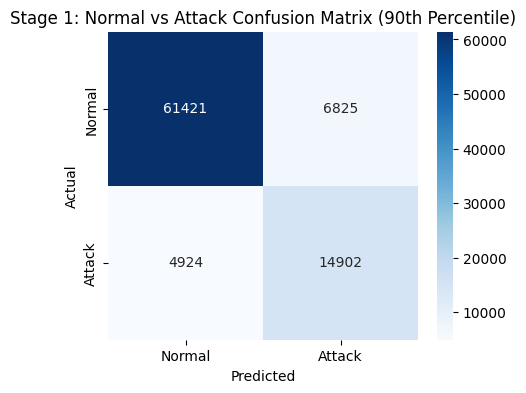

In [ ]:
# =========================
# STAGE 1: NORMAL VS ATTACK EVALUATION
# =========================

# Final threshold (90th percentile)
threshold_stage1 = np.percentile(errors_val_benign, 90)

# Binary prediction: 0 = Normal, 1 = Attack
y_pred_stage1 = (errors_val_all > threshold_stage1).astype(int)

print("Stage 1 Task: Normal vs Attack")
print("Threshold: 90th percentile")
print("Threshold value:", threshold_stage1)

print("\nClassification Report:")
print(classification_report(y_val_binary, y_pred_stage1, zero_division=0))

cm_stage1 = confusion_matrix(y_val_binary, y_pred_stage1)

print("\nConfusion Matrix:")
print(cm_stage1)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_stage1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title("Stage 1: Normal vs Attack Confusion Matrix (90th Percentile)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

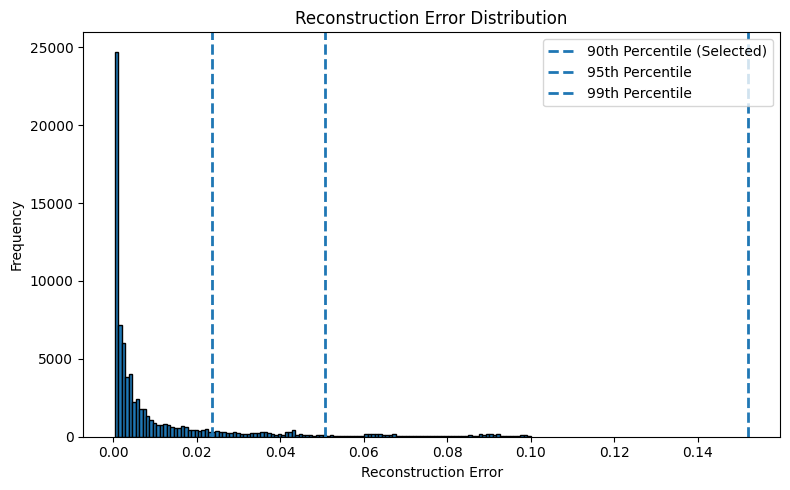

In [ ]:
# =========================
# RECONSTRUCTION ERROR DISTRIBUTION (FINAL)
# =========================

threshold_90 = np.percentile(errors_val_benign, 90)
threshold_95 = np.percentile(errors_val_benign, 95)
threshold_99 = np.percentile(errors_val_benign, 99)

# Outlier-ları vizual üçün kəsirik (modelə təsir etmir)
errors_filtered = errors_val_all[errors_val_all < 0.1]

plt.figure(figsize=(8,5))

plt.hist(errors_filtered, bins=120, edgecolor='black')

plt.axvline(threshold_90, linestyle="--", linewidth=2, label="90th Percentile (Selected)")
plt.axvline(threshold_95, linestyle="--", linewidth=2, label="95th Percentile")
plt.axvline(threshold_99, linestyle="--", linewidth=2, label="99th Percentile")

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()